# Practical Post-Modeling Steps with scikit-learn

You will practice:

1. Offline evaluation for regression models
2. Offline evaluation for classification models
3. Confusion matrix, accuracy, cost-sensitive accuracy, precision, recall, F1-score, ROC and AUC
4. Threshold tuning for different business / risk objectives
5. Online evaluation with a simple A/B-test simulation
6. Model deployment preparation with `joblib`
7. Batch serving and single-query serving
8. Monitoring for performance, latency, prediction distribution, and data drift
9. Maintenance decisions and retraining triggers

The notebook uses built-in scikit-learn datasets, so no external data download is required.

## 0. Setup

Run this cell first. The notebook uses standard scientific Python packages and scikit-learn.

In [1]:
import json
import math
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.base import clone
from sklearn.datasets import load_breast_cancer, load_diabetes, load_digits
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    r2_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

print("Notebook ready.")

Notebook ready.


## 1. Offline evaluation for regression

In the lecture, regression evaluation is introduced through MSE, RMSE, MAE, and R². Here we make this practical by training several models and comparing them on validation and test sets.

**Workflow**

1. Load a regression dataset.
2. Split into train, validation, and test sets.
3. Train candidate models.
4. Compare validation metrics.
5. Select the best model.
6. Report final test-set performance.

In [2]:
# Load a built-in regression dataset
reg_data = load_diabetes(as_frame=True)
X_reg = reg_data.data
y_reg = reg_data.target

print("Regression dataset shape:", X_reg.shape)
display(X_reg.head())

Regression dataset shape: (442, 10)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [3]:
# Train / validation / test split: 60% / 20% / 20%
X_train_reg, X_temp_reg, y_train_reg, y_temp_reg = train_test_split(
    X_reg, y_reg, test_size=0.40, random_state=RANDOM_STATE
)

X_valid_reg, X_test_reg, y_valid_reg, y_test_reg = train_test_split(
    X_temp_reg, y_temp_reg, test_size=0.50, random_state=RANDOM_STATE
)

print("Train:", X_train_reg.shape)
print("Validation:", X_valid_reg.shape)
print("Test:", X_test_reg.shape)

Train: (265, 10)
Validation: (88, 10)
Test: (89, 10)


In [4]:
def regression_metrics(y_true, y_pred):
    """Return common regression metrics in a dictionary."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
    }

regression_models = {
    "LinearRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "GradientBoostingRegressor": GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),
}

validation_rows = []

for name, model in regression_models.items():
    model.fit(X_train_reg, y_train_reg)
    y_valid_pred = model.predict(X_valid_reg)
    metrics = regression_metrics(y_valid_reg, y_valid_pred)
    metrics["model"] = name
    validation_rows.append(metrics)

reg_valid_results = pd.DataFrame(validation_rows).set_index("model").sort_values("RMSE")
display(reg_valid_results)

,MSE,RMSE,MAE,R2
model,,,,
LinearRegression,2415.692270,49.149692,38.221274,0.580967
RandomForestRegressor,2859.003604,53.469651,42.137424,0.504069
GradientBoostingRegressor,2909.926021,53.943730,43.238381,0.495235


In [5]:
# Select the model with the lowest validation RMSE
best_reg_name = reg_valid_results.index[0]
best_reg_model = regression_models[best_reg_name]

print("Best validation model:", best_reg_name)

# Final test evaluation
reg_test_pred = best_reg_model.predict(X_test_reg)
reg_test_metrics = regression_metrics(y_test_reg, reg_test_pred)

display(pd.DataFrame([reg_test_metrics], index=[best_reg_name]))

Best validation model: LinearRegression


,MSE,RMSE,MAE,R2
LinearRegression,3245.611401,56.970268,46.724017,0.438914


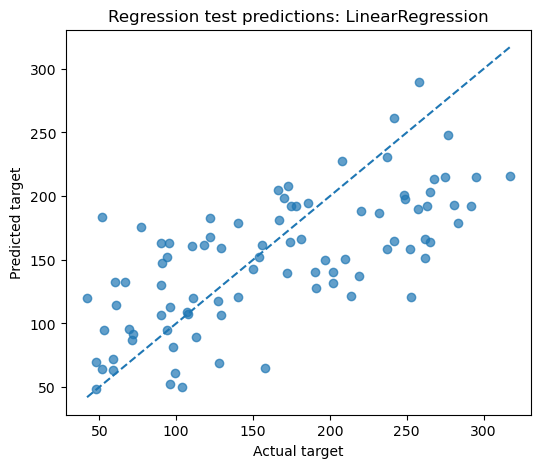

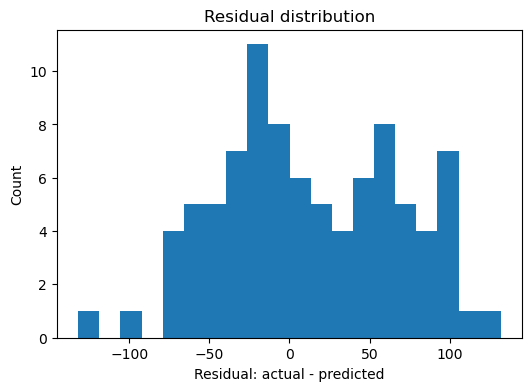

In [6]:
# Visual inspection: actual vs predicted values
plt.figure(figsize=(6, 5))
plt.scatter(y_test_reg, reg_test_pred, alpha=0.7)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], linestyle="--")
plt.xlabel("Actual target")
plt.ylabel("Predicted target")
plt.title(f"Regression test predictions: {best_reg_name}")
plt.show()

# Residual plot
residuals = y_test_reg - reg_test_pred
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=20)
plt.xlabel("Residual: actual - predicted")
plt.ylabel("Count")
plt.title("Residual distribution")
plt.show()

### Interpretation checkpoint

Use the table and plots above to answer:

- Which model has the lowest validation RMSE?
- Is the test RMSE close to the validation RMSE?
- Are residuals centered around zero?
- Is R² high enough for the problem context?

In real projects, a model is not selected only because it has the best metric. You also consider interpretability, latency, maintenance cost, and risk.

## 2. Offline evaluation for classification

The lecture covers confusion matrix, accuracy, cost-sensitive accuracy, precision, recall, F1-score, ROC, and AUC. We now implement these metrics in a binary classification example.

We use the breast cancer dataset. To make the positive class meaningful, we define:

- `1 = malignant`
- `0 = benign`

This lets us discuss the cost of false negatives: predicting benign when the case is actually malignant.

In [7]:
clf_data = load_breast_cancer(as_frame=True)
X_clf = clf_data.data

# Original sklearn target: 0 = malignant, 1 = benign.
# We remap it so the positive class 1 means malignant.
y_clf = pd.Series((clf_data.target == 0).astype(int), name="malignant", index=X_clf.index)

print("Classification dataset shape:", X_clf.shape)
print("Class distribution, where 1 = malignant and 0 = benign:")
display(y_clf.value_counts().rename(index={1: "malignant", 0: "benign"}))
display(X_clf.head())

Classification dataset shape: (569, 30)
Class distribution, where 1 = malignant and 0 = benign:


malignant
benign       357
malignant    212
Name: count, dtype: int64

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [8]:
# Train / validation / test split: 60% / 20% / 20%
X_train_clf, X_temp_clf, y_train_clf, y_temp_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.40,
    random_state=RANDOM_STATE,
    stratify=y_clf,
)

X_valid_clf, X_test_clf, y_valid_clf, y_test_clf = train_test_split(
    X_temp_clf,
    y_temp_clf,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp_clf,
)

print("Train:", X_train_clf.shape)
print("Validation:", X_valid_clf.shape)
print("Test:", X_test_clf.shape)

Train: (341, 30)
Validation: (114, 30)
Test: (114, 30)


In [9]:
def binary_classification_metrics(y_true, y_pred, y_score=None):
    """Return common classification metrics for positive class = 1."""
    output = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        output["roc_auc"] = roc_auc_score(y_true, y_score)
    return output

clf_models = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
    ]),
    "LogisticRegression_balanced": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "RandomForestClassifier": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced"
    ),
}

validation_rows = []

for name, model in clf_models.items():
    model.fit(X_train_clf, y_train_clf)
    y_valid_pred = model.predict(X_valid_clf)
    y_valid_score = model.predict_proba(X_valid_clf)[:, 1]
    row = binary_classification_metrics(y_valid_clf, y_valid_pred, y_valid_score)
    row["model"] = name
    validation_rows.append(row)

clf_valid_results = pd.DataFrame(validation_rows).set_index("model").sort_values("f1", ascending=False)
display(clf_valid_results)

,accuracy,precision,recall,f1,roc_auc
model,,,,,
LogisticRegression_balanced,0.982456,1.00000,0.953488,0.976190,1.000000
LogisticRegression,0.973684,1.00000,0.930233,0.963855,1.000000
RandomForestClassifier,0.964912,0.97561,0.930233,0.952381,0.998035


In [10]:
# Select the model with the highest validation F1-score
best_clf_name = clf_valid_results.index[0]
best_clf = clf_models[best_clf_name]

print("Best validation classifier:", best_clf_name)

# Test-set prediction with the default threshold 0.5
clf_test_score = best_clf.predict_proba(X_test_clf)[:, 1]
clf_test_pred_default = (clf_test_score >= 0.50).astype(int)

test_metrics_default = binary_classification_metrics(y_test_clf, clf_test_pred_default, clf_test_score)
display(pd.DataFrame([test_metrics_default], index=[f"{best_clf_name}, threshold=0.50"]))

Best validation classifier: LogisticRegression_balanced


,accuracy,precision,recall,f1,roc_auc
"LogisticRegression_balanced, threshold=0.50",0.95614,0.974359,0.904762,0.938272,0.992725


### 2.1 Confusion matrix

For binary classification with positive class `1 = malignant`:

- **TP**: actually malignant and predicted malignant
- **TN**: actually benign and predicted benign
- **FP**: actually benign but predicted malignant
- **FN**: actually malignant but predicted benign

In many safety-related settings, FN may be more costly than FP.

In [11]:
def confusion_matrix_dataframe(y_true, y_pred):
    # labels=[1, 0] gives a matrix ordered as malignant first, benign second.
    cm = confusion_matrix(y_true, y_pred, labels=[1, 0])
    return pd.DataFrame(
        cm,
        index=["actual_malignant", "actual_benign"],
        columns=["predicted_malignant", "predicted_benign"]
    )

cm_default = confusion_matrix_dataframe(y_test_clf, clf_test_pred_default)
display(cm_default)

print(classification_report(
    y_test_clf,
    clf_test_pred_default,
    target_names=["benign", "malignant"],
    zero_division=0
))

,predicted_malignant,predicted_benign
actual_malignant,38,4
actual_benign,1,71


              precision    recall  f1-score   support

      benign       0.95      0.99      0.97        72
   malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



### 2.2 Cost-sensitive accuracy

Accuracy treats all mistakes equally. Cost-sensitive accuracy lets us assign different costs to false positives and false negatives.

In this example:

- `cost_fp = 1`: benign case predicted as malignant
- `cost_fn = 10`: malignant case predicted as benign

The second mistake is much more serious in this example.

In [12]:
def cost_sensitive_accuracy(y_true, y_pred, cost_fp=1, cost_fn=10):
    """
    Cost-sensitive accuracy based on weighted FP and FN counts.
    Positive class = 1.
    Formula: (TP + TN) / (TP + TN + cost_fp*FP + cost_fn*FN)
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return (tp + tn) / (tp + tn + cost_fp * fp + cost_fn * fn)

print("Default threshold 0.50")
print("Standard accuracy:", accuracy_score(y_test_clf, clf_test_pred_default))
print("Cost-sensitive accuracy:", cost_sensitive_accuracy(y_test_clf, clf_test_pred_default, cost_fp=1, cost_fn=10))

Default threshold 0.50
Standard accuracy: 0.956140350877193
Cost-sensitive accuracy: 0.7266666666666667


## 3. Threshold tuning: precision-recall trade-off

Many classifiers output probabilities. A default threshold of 0.5 is not always appropriate.

- Higher threshold usually increases precision but reduces recall.
- Lower threshold usually increases recall but may reduce precision.
- For high-risk use cases, we may prefer high recall to reduce false negatives.

In [13]:
valid_scores = best_clf.predict_proba(X_valid_clf)[:, 1]
thresholds = np.linspace(0.05, 0.95, 19)

threshold_rows = []
for threshold in thresholds:
    pred = (valid_scores >= threshold).astype(int)
    row = binary_classification_metrics(y_valid_clf, pred, valid_scores)
    row["threshold"] = threshold
    row["cost_sensitive_accuracy"] = cost_sensitive_accuracy(
        y_valid_clf,
        pred,
        cost_fp=1,
        cost_fn=10,
    )
    threshold_rows.append(row)

threshold_results = pd.DataFrame(threshold_rows).set_index("threshold")
display(threshold_results)

,accuracy,precision,recall,f1,roc_auc,cost_sensitive_accuracy
threshold,,,,,,
0.05,0.938596,0.860000,1.000000,0.924731,1.0,0.938596
0.10,0.964912,0.914894,1.000000,0.955556,1.0,0.964912
0.15,0.973684,0.934783,1.000000,0.966292,1.0,0.973684
0.20,0.991228,0.977273,1.000000,0.988506,1.0,0.991228
0.25,0.991228,0.977273,1.000000,0.988506,1.0,0.991228
0.30,0.991228,0.977273,1.000000,0.988506,1.0,0.991228
0.35,1.000000,1.000000,1.000000,1.000000,1.0,1.000000
0.40,0.991228,1.000000,0.976744,0.988235,1.0,0.918699
0.45,0.982456,1.000000,0.953488,0.976190,1.0,0.848485


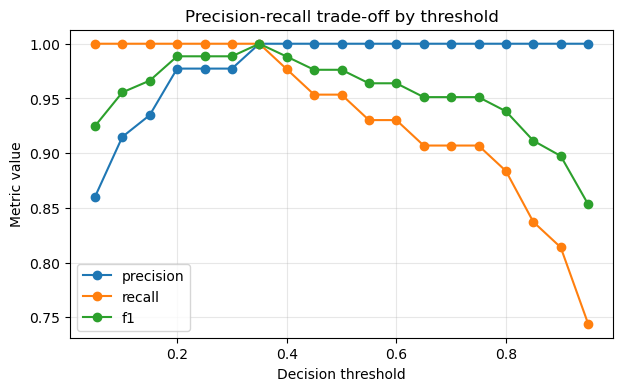

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(threshold_results.index, threshold_results["precision"], marker="o", label="precision")
plt.plot(threshold_results.index, threshold_results["recall"], marker="o", label="recall")
plt.plot(threshold_results.index, threshold_results["f1"], marker="o", label="f1")
plt.xlabel("Decision threshold")
plt.ylabel("Metric value")
plt.title("Precision-recall trade-off by threshold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
# Choose threshold that maximizes cost-sensitive accuracy on the validation set
best_threshold = threshold_results["cost_sensitive_accuracy"].idxmax()
print("Selected threshold:", best_threshold)

# Evaluate selected threshold on the test set
test_pred_tuned = (clf_test_score >= best_threshold).astype(int)

test_metrics_tuned = binary_classification_metrics(y_test_clf, test_pred_tuned, clf_test_score)
test_metrics_tuned["cost_sensitive_accuracy"] = cost_sensitive_accuracy(
    y_test_clf,
    test_pred_tuned,
    cost_fp=1,
    cost_fn=10,
)

comparison = pd.DataFrame([
    {**test_metrics_default, "cost_sensitive_accuracy": cost_sensitive_accuracy(y_test_clf, clf_test_pred_default, cost_fp=1, cost_fn=10)},
    test_metrics_tuned,
], index=["default threshold 0.50", f"tuned threshold {best_threshold:.2f}"])

display(comparison)
display(confusion_matrix_dataframe(y_test_clf, test_pred_tuned))

Selected threshold: 0.35


,accuracy,precision,recall,f1,roc_auc,cost_sensitive_accuracy
default threshold 0.50,0.956140,0.974359,0.904762,0.938272,0.992725,0.726667
tuned threshold 0.35,0.973684,0.975610,0.952381,0.963855,0.992725,0.840909


,predicted_malignant,predicted_benign
actual_malignant,40,2
actual_benign,1,71


## 4. ROC curve and AUC

ROC curves compare true positive rate and false positive rate across thresholds. AUC summarizes the curve into one number.

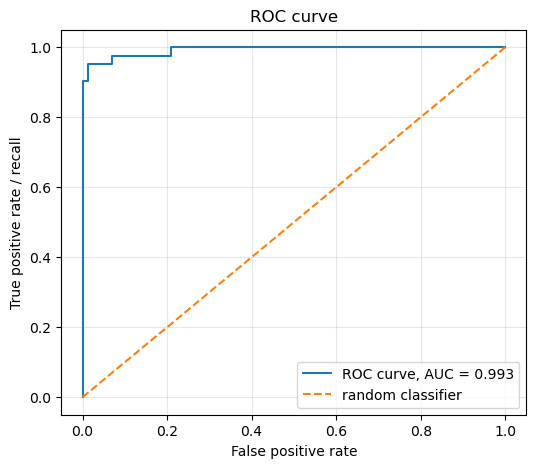

In [16]:
fpr, tpr, roc_thresholds = roc_curve(y_test_clf, clf_test_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve, AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="random classifier")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate / recall")
plt.title("ROC curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Multi-class classification: macro, micro, and weighted F1

For multi-class problems, precision, recall, and F1 can be averaged in different ways.

- **Macro average**: treats all classes equally.
- **Weighted average**: weights each class by its support.
- **Micro average**: aggregates all decisions globally; in single-label multi-class classification it equals accuracy.

In [17]:
digits = load_digits(as_frame=True)
X_digits = digits.data
y_digits = digits.target

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_digits,
    y_digits,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_digits,
)

digit_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
digit_model.fit(X_train_d, y_train_d)
y_pred_d = digit_model.predict(X_test_d)

print("Accuracy:", accuracy_score(y_test_d, y_pred_d))
print("Macro F1:", f1_score(y_test_d, y_pred_d, average="macro"))
print("Weighted F1:", f1_score(y_test_d, y_pred_d, average="weighted"))
print("Micro F1:", f1_score(y_test_d, y_pred_d, average="micro"))

report_d = classification_report(y_test_d, y_pred_d, output_dict=True, zero_division=0)
display(pd.DataFrame(report_d).T)

Accuracy: 0.9688888888888889
Macro F1: 0.9683455138532511
Weighted F1: 0.9685889650389191
Micro F1: 0.9688888888888889


,precision,recall,f1-score,support
0,1.000000,0.955556,0.977273,45.000000
1,0.937500,0.978261,0.957447,46.000000
2,1.000000,1.000000,1.000000,44.000000
3,0.958333,1.000000,0.978723,46.000000
4,0.957447,1.000000,0.978261,45.000000
5,0.978261,0.978261,0.978261,46.000000
6,1.000000,0.977778,0.988764,45.000000
7,0.937500,1.000000,0.967742,45.000000
8,0.948718,0.860465,0.902439,43.000000
9,0.976744,0.933333,0.954545,45.000000


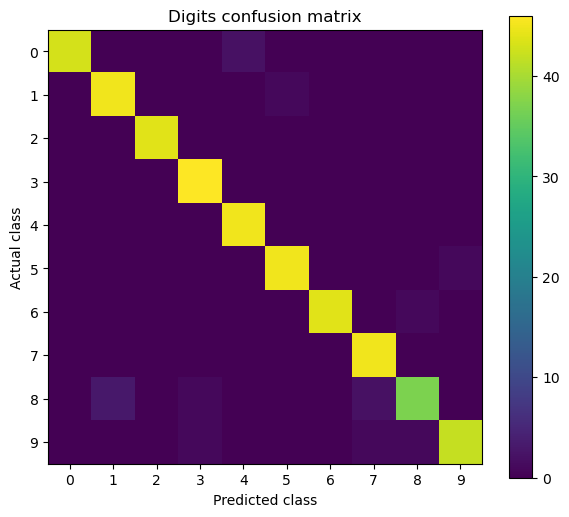

In [18]:
cm_digits = confusion_matrix(y_test_d, y_pred_d)

plt.figure(figsize=(7, 6))
plt.imshow(cm_digits)
plt.title("Digits confusion matrix")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.colorbar()
plt.xticks(range(10))
plt.yticks(range(10))
plt.show()

## 6. Online evaluation: simple A/B testing simulation

Offline metrics tell us how the model performs on historical data. Online evaluation checks whether the new model improves a business outcome in production.

In this simulation, we compare two model versions:

- Version A: old model
- Version B: new model

The business metric is conversion rate.

In [19]:
rng = np.random.default_rng(RANDOM_STATE)

n_A = 5000
n_B = 5000
true_conversion_A = 0.082
true_conversion_B = 0.091

conversions_A = rng.binomial(1, true_conversion_A, size=n_A)
conversions_B = rng.binomial(1, true_conversion_B, size=n_B)

summary_ab = pd.DataFrame({
    "group": ["A_old_model", "B_new_model"],
    "users": [n_A, n_B],
    "conversions": [conversions_A.sum(), conversions_B.sum()],
    "conversion_rate": [conversions_A.mean(), conversions_B.mean()],
})

display(summary_ab)

,group,users,conversions,conversion_rate
0,A_old_model,5000,411,0.0822
1,B_new_model,5000,448,0.0896


In [20]:
def two_proportion_z_test(success_A, n_A, success_B, n_B):
    """Two-sided two-proportion z-test implemented with standard Python math."""
    p_A = success_A / n_A
    p_B = success_B / n_B
    p_pool = (success_A + success_B) / (n_A + n_B)
    se = math.sqrt(p_pool * (1 - p_pool) * (1 / n_A + 1 / n_B))
    z = (p_B - p_A) / se
    p_value = math.erfc(abs(z) / math.sqrt(2))
    return z, p_value

z, p_value = two_proportion_z_test(
    conversions_A.sum(), n_A,
    conversions_B.sum(), n_B,
)

print(f"z-statistic: {z:.3f}")
print(f"p-value: {p_value:.5f}")

alpha = 0.05
if p_value < alpha:
    print("Decision: statistically significant difference at alpha = 0.05.")
else:
    print("Decision: not statistically significant at alpha = 0.05.")

z-statistic: 1.320
p-value: 0.18670
Decision: not statistically significant at alpha = 0.05.


### Optional: canary deployment simulation

In canary deployment, only a small fraction of users receives the new model at first.

In [21]:
def assign_canary_users(n_users, canary_fraction=0.05, random_state=42):
    rng = np.random.default_rng(random_state)
    assignments = rng.choice(
        ["old_model", "new_model"],
        size=n_users,
        p=[1 - canary_fraction, canary_fraction]
    )
    return pd.Series(assignments).value_counts().rename("number_of_users")

assign_canary_users(n_users=10000, canary_fraction=0.05)

old_model    9499
new_model     501
Name: number_of_users, dtype: int64

### Optional: multi-armed bandit deployment simulation

A multi-armed bandit uses exploration and exploitation. It initially tries multiple model versions, then gradually sends more traffic to the better-performing model.

In [22]:
def run_epsilon_greedy_bandit(true_rates, n_rounds=5000, epsilon=0.10, random_state=42):
    rng = np.random.default_rng(random_state)
    n_arms = len(true_rates)
    counts = np.zeros(n_arms, dtype=int)
    successes = np.zeros(n_arms, dtype=int)

    for t in range(n_rounds):
        # Try each arm once at the beginning.
        if t < n_arms:
            arm = t
        else:
            if rng.random() < epsilon:
                arm = rng.integers(0, n_arms)
            else:
                estimated_rates = successes / np.maximum(counts, 1)
                arm = int(np.argmax(estimated_rates))

        reward = rng.binomial(1, true_rates[arm])
        counts[arm] += 1
        successes[arm] += reward

    return pd.DataFrame({
        "arm": [f"model_{i}" for i in range(n_arms)],
        "true_rate": true_rates,
        "times_served": counts,
        "observed_successes": successes,
        "observed_rate": successes / counts,
    })

bandit_result = run_epsilon_greedy_bandit([0.082, 0.091, 0.087], n_rounds=5000, epsilon=0.10)
display(bandit_result)

,arm,true_rate,times_served,observed_successes,observed_rate
0,model_0,0.082,388,34,0.087629
1,model_1,0.091,1987,168,0.084550
2,model_2,0.087,2625,241,0.091810


## 7. Deployment preparation: save the trained model

A model should be saved together with important metadata:

- model version
- selected threshold
- feature names
- training timestamp or owner information
- evaluation metrics

Here we save a scikit-learn pipeline with `joblib`.

In [23]:
MODEL_VERSION = "v1"
MODEL_PATH = ARTIFACT_DIR / f"breast_cancer_classifier_{MODEL_VERSION}.joblib"
MODEL_CARD_PATH = ARTIFACT_DIR / f"breast_cancer_classifier_{MODEL_VERSION}_model_card.json"

model_bundle = {
    "model": best_clf,
    "threshold": float(best_threshold),
    "feature_names": list(X_clf.columns),
    "positive_class": "malignant",
    "version": MODEL_VERSION,
}

joblib.dump(model_bundle, MODEL_PATH)

model_card = {
    "model_name": "Breast cancer classification example",
    "version": MODEL_VERSION,
    "framework": "scikit-learn",
    "selected_model": best_clf_name,
    "positive_class": "malignant",
    "threshold": float(best_threshold),
    "validation_selection_metric": "cost_sensitive_accuracy",
    "test_metrics_default_threshold": test_metrics_default,
    "test_metrics_tuned_threshold": test_metrics_tuned,
    "notes": "Educational example only. Not for medical use.",
}

with open(MODEL_CARD_PATH, "w", encoding="utf-8") as f:
    json.dump(model_card, f, indent=2)

print("Saved model to:", MODEL_PATH)
print("Saved model card to:", MODEL_CARD_PATH)

Saved model to: artifacts\breast_cancer_classifier_v1.joblib
Saved model card to: artifacts\breast_cancer_classifier_v1_model_card.json


## 8. Model serving: single prediction and batch prediction

Serving means making the model available for scoring new inputs. In this notebook, we simulate serving locally.

- **Single-query serving**: score one user / one record.
- **Batch serving**: score many records at once.

In [24]:
loaded_bundle = joblib.load(MODEL_PATH)
loaded_model = loaded_bundle["model"]
loaded_threshold = loaded_bundle["threshold"]
feature_names = loaded_bundle["feature_names"]


def predict_single(input_features):
    """
    Score one example.
    input_features can be a dictionary with feature names or a one-row DataFrame.
    """
    if isinstance(input_features, dict):
        X_input = pd.DataFrame([input_features], columns=feature_names)
    else:
        X_input = input_features[feature_names]

    probability = loaded_model.predict_proba(X_input)[:, 1][0]
    prediction = int(probability >= loaded_threshold)
    return {
        "probability_malignant": float(probability),
        "prediction": prediction,
        "prediction_label": "malignant" if prediction == 1 else "benign",
        "threshold": float(loaded_threshold),
    }

example_record = X_test_clf.iloc[0].to_dict()
predict_single(example_record)

{'probability_malignant': 0.008047535770654432,
 'prediction': 0,
 'prediction_label': 'benign',
 'threshold': 0.35}

In [25]:
def predict_batch(X_batch):
    """Score many examples at once."""
    X_batch = X_batch[feature_names]
    probabilities = loaded_model.predict_proba(X_batch)[:, 1]
    predictions = (probabilities >= loaded_threshold).astype(int)
    return pd.DataFrame({
        "probability_malignant": probabilities,
        "prediction": predictions,
        "prediction_label": np.where(predictions == 1, "malignant", "benign"),
    }, index=X_batch.index)

batch_predictions = predict_batch(X_test_clf.head(10))
display(batch_predictions)

,probability_malignant,prediction,prediction_label
84,0.008048,0,benign
123,0.036398,0,benign
107,0.006450,0,benign
183,0.000122,0,benign
20,0.002378,0,benign
410,0.089897,0,benign
310,0.003544,0,benign
469,0.262099,0,benign
176,0.000058,0,benign
15,0.999234,1,malignant


### Optional: generate a minimal FastAPI app

The lecture shows a REST API deployment pattern. The cell below writes an `app.py` file, but does not start the server automatically.

To run it outside the notebook, install FastAPI and Uvicorn, then execute:

```bash
uvicorn artifacts.app:app --reload --port 8000
```

This is optional. The main ML workflow remains scikit-learn-based.

In [26]:
app_code = f"""
from pathlib import Path
from typing import Dict

import joblib
import pandas as pd
from fastapi import FastAPI
from pydantic import BaseModel

MODEL_PATH = Path(__file__).parent / "breast_cancer_classifier_v1.joblib"
bundle = joblib.load(MODEL_PATH)
model = bundle["model"]
threshold = bundle["threshold"]
feature_names = bundle["feature_names"]

app = FastAPI(title="Scikit-learn model serving example")

class PredictionInput(BaseModel):
    features: Dict[str, float]

@app.get("/")
def root():
    return {{"status": "ok", "model_version": bundle["version"]}}

@app.post("/predict")
def predict(payload: PredictionInput):
    X = pd.DataFrame([payload.features], columns=feature_names)
    probability = float(model.predict_proba(X)[:, 1][0])
    prediction = int(probability >= threshold)
    return {{
        "probability_malignant": probability,
        "prediction": prediction,
        "prediction_label": "malignant" if prediction == 1 else "benign",
        "threshold": float(threshold),
    }}
"""

app_path = ARTIFACT_DIR / "app.py"
app_path.write_text(app_code, encoding="utf-8")
print("FastAPI app written to:", app_path)

FastAPI app written to: artifacts\app.py


## 9. Monitoring after deployment

A deployed model should be monitored continuously. Practical monitoring can include:

- prediction statistics: min, max, mean, standard deviation
- predicted class distribution
- latency
- number of servings
- performance metrics when labels become available
- data drift using indicators such as Population Stability Index (PSI)

Below we simulate a normal production batch and a shifted production batch.

In [27]:
def population_stability_index(expected, actual, bins=10):
    """
    Compute Population Stability Index (PSI) between two numeric distributions.
    Higher values suggest stronger distribution shift.
    Common rough interpretation:
        PSI < 0.10: small change
        0.10 <= PSI < 0.25: moderate change
        PSI >= 0.25: large change
    """
    expected = np.asarray(expected, dtype=float)
    actual = np.asarray(actual, dtype=float)

    quantiles = np.linspace(0, 1, bins + 1)
    cuts = np.unique(np.quantile(expected, quantiles))

    if len(cuts) < 3:
        min_value = min(expected.min(), actual.min())
        max_value = max(expected.max(), actual.max())
        cuts = np.linspace(min_value, max_value, bins + 1)

    cuts[0] = -np.inf
    cuts[-1] = np.inf

    expected_counts, _ = np.histogram(expected, bins=cuts)
    actual_counts, _ = np.histogram(actual, bins=cuts)

    expected_pct = np.clip(expected_counts / len(expected), 1e-6, None)
    actual_pct = np.clip(actual_counts / len(actual), 1e-6, None)

    psi = np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))
    return float(psi)


def feature_psi_report(reference_X, current_X, top_n=10):
    rows = []
    for feature in reference_X.columns:
        psi = population_stability_index(reference_X[feature], current_X[feature])
        rows.append({"feature": feature, "psi": psi})
    return pd.DataFrame(rows).sort_values("psi", ascending=False).head(top_n)

In [28]:
def monitor_batch(model_bundle, X_batch, y_true=None, reference_scores=None):
    model = model_bundle["model"]
    threshold = model_bundle["threshold"]
    feature_names = model_bundle["feature_names"]

    X_batch = X_batch[feature_names]

    start = time.perf_counter()
    scores = model.predict_proba(X_batch)[:, 1]
    predictions = (scores >= threshold).astype(int)
    elapsed = time.perf_counter() - start

    report = {
        "batch_size": len(X_batch),
        "latency_total_ms": elapsed * 1000,
        "latency_per_record_ms": elapsed * 1000 / len(X_batch),
        "score_min": float(np.min(scores)),
        "score_max": float(np.max(scores)),
        "score_mean": float(np.mean(scores)),
        "score_std": float(np.std(scores)),
        "predicted_positive_rate": float(np.mean(predictions)),
        "number_predicted_positive": int(np.sum(predictions)),
        "number_predicted_negative": int(len(predictions) - np.sum(predictions)),
    }

    if reference_scores is not None:
        report["score_psi_vs_reference"] = population_stability_index(reference_scores, scores)

    if y_true is not None:
        report["accuracy"] = accuracy_score(y_true, predictions)
        report["precision"] = precision_score(y_true, predictions, zero_division=0)
        report["recall"] = recall_score(y_true, predictions, zero_division=0)
        report["f1"] = f1_score(y_true, predictions, zero_division=0)

    return report

In [29]:
# Reference scores from validation data
reference_scores = loaded_model.predict_proba(X_valid_clf[feature_names])[:, 1]

# Simulate a normal production batch
normal_batch_X = X_test_clf.sample(100, random_state=1)
normal_batch_y = y_test_clf.loc[normal_batch_X.index]

normal_report = monitor_batch(
    loaded_bundle,
    normal_batch_X,
    y_true=normal_batch_y,
    reference_scores=reference_scores,
)

display(pd.DataFrame([normal_report], index=["normal_batch"]))

,batch_size,latency_total_ms,latency_per_record_ms,score_min,score_max,score_mean,score_std,predicted_positive_rate,number_predicted_positive,number_predicted_negative,score_psi_vs_reference,accuracy,precision,recall,f1
normal_batch,100,1.5986,0.015986,0.000058,1.0,0.3798,0.450372,0.37,37,63,0.204665,0.97,0.972973,0.947368,0.96


In [30]:
# Simulate a shifted production batch by changing several features.
# This is artificial, but it helps demonstrate monitoring.
shifted_batch_X = X_test_clf.sample(100, random_state=2).copy()
shifted_batch_y = y_test_clf.loc[shifted_batch_X.index]

for feature in ["mean radius", "mean texture", "worst area"]:
    shifted_batch_X[feature] = shifted_batch_X[feature] * 1.25

shifted_report = monitor_batch(
    loaded_bundle,
    shifted_batch_X,
    y_true=shifted_batch_y,
    reference_scores=reference_scores,
)

display(pd.DataFrame([normal_report, shifted_report], index=["normal_batch", "shifted_batch"]))

,batch_size,latency_total_ms,latency_per_record_ms,score_min,score_max,score_mean,score_std,predicted_positive_rate,number_predicted_positive,number_predicted_negative,score_psi_vs_reference,accuracy,precision,recall,f1
normal_batch,100,1.5986,0.015986,0.000058,1.0,0.379800,0.450372,0.37,37,63,0.204665,0.97,0.972973,0.947368,0.960000
shifted_batch,100,2.1335,0.021335,0.000122,1.0,0.396827,0.438252,0.39,39,61,0.502390,0.95,0.897436,0.972222,0.933333


In [31]:
# Feature-level drift report
feature_drift = feature_psi_report(X_valid_clf[feature_names], shifted_batch_X[feature_names], top_n=10)
display(feature_drift)

,feature,psi
1,mean texture,2.083593
0,mean radius,1.397826
23,worst area,0.653049
16,concavity error,0.412253
7,mean concave points,0.327749
24,worst smoothness,0.312822
10,radius error,0.297128
3,mean area,0.269504
2,mean perimeter,0.239930
21,worst texture,0.238275


## 10. Maintenance decision: should we retrain?

A simple maintenance rule can combine performance and drift signals.

Example rule:

- Retrain if F1 drops more than 0.05 compared with the baseline validation F1, or
- Retrain if score PSI is greater than 0.25, or
- Investigate if important feature PSI values are greater than 0.25.

Real systems usually need stronger governance: human review, rollback, model registry, audit logs, and production validation.

In [32]:
# Baseline validation report with labels
baseline_validation_report = monitor_batch(
    loaded_bundle,
    X_valid_clf,
    y_true=y_valid_clf,
    reference_scores=reference_scores,
)

baseline_f1 = baseline_validation_report["f1"]
current_f1 = shifted_report["f1"]
current_score_psi = shifted_report["score_psi_vs_reference"]
max_feature_psi = feature_drift["psi"].max()

print("Baseline validation F1:", round(baseline_f1, 4))
print("Current shifted-batch F1:", round(current_f1, 4))
print("Current score PSI:", round(current_score_psi, 4))
print("Max feature PSI:", round(max_feature_psi, 4))

should_retrain = (
    current_f1 < baseline_f1 - 0.05
    or current_score_psi > 0.25
    or max_feature_psi > 0.25
)

if should_retrain:
    print("Decision: retraining or deeper investigation is recommended.")
else:
    print("Decision: continue monitoring.")

Baseline validation F1: 1.0
Current shifted-batch F1: 0.9333
Current score PSI: 0.5024
Max feature PSI: 2.0836
Decision: retraining or deeper investigation is recommended.


In [33]:
# Example maintenance action: retrain a new version with additional labeled production data.
# In this toy example, we use the shifted batch and its labels as if labels have arrived later.

if should_retrain:
    X_retrain = pd.concat([X_train_clf, X_valid_clf, shifted_batch_X], axis=0)
    y_retrain = pd.concat([y_train_clf, y_valid_clf, shifted_batch_y], axis=0)

    model_v2 = clone(best_clf)
    model_v2.fit(X_retrain, y_retrain)

    test_scores_v2 = model_v2.predict_proba(X_test_clf)[:, 1]
    test_pred_v2 = (test_scores_v2 >= best_threshold).astype(int)

    v2_metrics = binary_classification_metrics(y_test_clf, test_pred_v2, test_scores_v2)
    display(pd.DataFrame([test_metrics_tuned, v2_metrics], index=["v1_tuned", "v2_retrained"]))

    bundle_v2 = {
        "model": model_v2,
        "threshold": float(best_threshold),
        "feature_names": feature_names,
        "positive_class": "malignant",
        "version": "v2",
    }
    joblib.dump(bundle_v2, ARTIFACT_DIR / "breast_cancer_classifier_v2.joblib")
    print("Saved retrained model v2.")
else:
    print("No retraining performed.")

,accuracy,precision,recall,f1,roc_auc,cost_sensitive_accuracy
v1_tuned,0.973684,0.97561,0.952381,0.963855,0.992725,0.840909
v2_retrained,0.982456,0.97619,0.976190,0.976190,0.998347,NaN


Saved retrained model v2.


## 11. Practical exercises

Complete the exercises below. The solution cells are at the end of the notebook.

### Exercise 1: add another regression model

Add a new scikit-learn regression model to the regression comparison and evaluate it with RMSE, MAE, and R².

In [34]:
# Exercise 1
# Start your code here


# Stop your code here

### Exercise 2: change the cost-sensitive setting

Set `cost_fn = 20` and find the best threshold again. Compare it with the previous threshold.

In [ ]:
# Exercise 2
# Start your code here


# Stop your code here

### Exercise 3: canary deployment

Simulate a canary deployment where 10% of 20,000 users receive the new model.

In [ ]:
# Exercise 3
# Start your code here


# Stop your code here

### Exercise 4: add a monitoring metric

Extend the monitoring report with the median prediction score.

In [ ]:
# Exercise 4
# Start your code here


# Stop your code here

### Exercise 5: maintenance decision

Create your own maintenance rule. For example, combine F1, recall, score PSI, and feature PSI.

In [ ]:
# Exercise 5
# Start your code here


# Stop your code here

---

# Solution section

Use this section after students have tried the exercises.

## Solution 1

In [ ]:
from sklearn.tree import DecisionTreeRegressor

extra_model = DecisionTreeRegressor(max_depth=4, random_state=RANDOM_STATE)
extra_model.fit(X_train_reg, y_train_reg)
extra_pred = extra_model.predict(X_valid_reg)

solution_1_metrics = regression_metrics(y_valid_reg, extra_pred)
display(pd.DataFrame([solution_1_metrics], index=["DecisionTreeRegressor"]))

## Solution 2

In [ ]:
threshold_rows_fn20 = []

for threshold in thresholds:
    pred = (valid_scores >= threshold).astype(int)
    row = binary_classification_metrics(y_valid_clf, pred, valid_scores)
    row["threshold"] = threshold
    row["cost_sensitive_accuracy"] = cost_sensitive_accuracy(
        y_valid_clf,
        pred,
        cost_fp=1,
        cost_fn=20,
    )
    threshold_rows_fn20.append(row)

threshold_results_fn20 = pd.DataFrame(threshold_rows_fn20).set_index("threshold")
best_threshold_fn20 = threshold_results_fn20["cost_sensitive_accuracy"].idxmax()

print("Best threshold with cost_fn=10:", best_threshold)
print("Best threshold with cost_fn=20:", best_threshold_fn20)
display(threshold_results_fn20.sort_values("cost_sensitive_accuracy", ascending=False).head())

## Solution 3

In [ ]:
canary_10_percent = assign_canary_users(n_users=20000, canary_fraction=0.10, random_state=RANDOM_STATE)
display(canary_10_percent)

## Solution 4

In [ ]:
def monitor_batch_with_median(model_bundle, X_batch, y_true=None, reference_scores=None):
    report = monitor_batch(model_bundle, X_batch, y_true=y_true, reference_scores=reference_scores)
    model = model_bundle["model"]
    feature_names = model_bundle["feature_names"]
    scores = model.predict_proba(X_batch[feature_names])[:, 1]
    report["score_median"] = float(np.median(scores))
    return report

median_report = monitor_batch_with_median(
    loaded_bundle,
    shifted_batch_X,
    y_true=shifted_batch_y,
    reference_scores=reference_scores,
)

display(pd.DataFrame([median_report], index=["shifted_batch_with_median"]))

## Solution 5

In [ ]:
custom_rule = {
    "f1_too_low": shifted_report["f1"] < baseline_f1 - 0.03,
    "recall_too_low": shifted_report["recall"] < 0.90,
    "score_drift_high": shifted_report["score_psi_vs_reference"] > 0.20,
    "feature_drift_high": max_feature_psi > 0.20,
}

display(pd.Series(custom_rule, name="triggered"))

if any(custom_rule.values()):
    print("Custom decision: investigate or retrain.")
else:
    print("Custom decision: continue monitoring.")